In [1]:
# !pip install lifelines

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Survival Analysis
from lifelines import CoxPHFitter

# Statistical Testing
from scipy.stats import pearsonr

In [3]:
online_retail_data=pd.read_excel('online_retail_II.xlsx')

In [4]:
online_retail_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
online_retail_data.shape

(525461, 8)

# Data Preprocessing

In [6]:
# Remove missing Customer IDs
online_retail_data = online_retail_data.dropna(subset=['Customer ID'])

In [7]:
# Remove duplicates
online_retail_data = online_retail_data.drop_duplicates()

In [8]:
# Remove returns (negative quantity)
online_retail_data = online_retail_data[online_retail_data['Quantity'] > 0]

In [9]:
# Convert datetime
online_retail_data['InvoiceDate'] = pd.to_datetime(online_retail_data['InvoiceDate'])

In [10]:
# Create Total Price
online_retail_data['TotalPrice'] = online_retail_data['Quantity'] * online_retail_data['Price']

In [11]:
# Rename column
online_retail_data.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

# Feature Engineering (RFM + Additional Features)

In [12]:
snapshot_date = online_retail_data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [13]:
rfm = online_retail_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [14]:
# Additional Features
tenure = online_retail_data.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max']).reset_index()
tenure['Tenure'] = (tenure['max'] - tenure['min']).dt.days

In [15]:
rfm = rfm.merge(tenure[['CustomerID', 'Tenure']], on='CustomerID')

In [16]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

In [17]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Tenure,AOV
0,12346.0,165,11,372.86,196,33.896364
1,12347.0,3,2,1323.32,37,661.660000
2,12348.0,74,1,222.16,0,222.160000
3,12349.0,43,3,2671.14,181,890.380000
4,12351.0,11,1,300.93,0,300.930000


# Define CLV Target

In [18]:
# Using Monetary as CLV proxy (can be extended)
rfm['CLV'] = rfm['Monetary']

# Hypothesis Testing

### H1: Frequency vs CLV

In [19]:
corr, p = pearsonr(rfm['Frequency'], rfm['CLV'])
print("H1 Correlation:", corr, "P-value:", p)

H1 Correlation: 0.6555132785090753 P-value: 0.0


### H2: Recency vs CLV

In [20]:
corr, p = pearsonr(rfm['Recency'], rfm['CLV'])
print("H2 Correlation:", corr, "P-value:", p)

H2 Correlation: -0.1208604374153779 P-value: 1.6502029144103664e-15


### H3: Monetary vs CLV

In [21]:
corr, p = pearsonr(rfm['Monetary'], rfm['CLV'])
print("H3 Correlation:", corr, "P-value:", p)

H3 Correlation: 1.0 P-value: 0.0


### H4: Tenure vs CLV

In [22]:
corr, p = pearsonr(rfm['Tenure'], rfm['CLV'])
print("H4 Correlation:", corr, "P-value:", p)

H4 Correlation: 0.2275030435541987 P-value: 9.202200747128789e-52


# Train-Test Split

In [23]:
X = rfm[['Recency', 'Frequency', 'Monetary', 'Tenure', 'AOV']]
y = rfm['CLV']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Baseline Regression Model

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred_lr = lr.predict(X_test)

In [26]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

MAE: 4.068752544874475e-12


In [27]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

RMSE: 9.837713675634261e-12


# Deep Learning Model

In [28]:
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [29]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
history = model.fit(
    X_train_lstm, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_lstm, y_test)
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 77016016.0000 - val_loss: 109537304.0000
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 77009424.0000 - val_loss: 109513360.0000
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 76990008.0000 - val_loss: 109464096.0000
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 76959872.0000 - val_loss: 109408168.0000
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 76924232.0000 - val_loss: 109342680.0000
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 76886520.0000 - val_loss: 109271816.0000
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 76843536.0000 - val_loss: 109196920.0000
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 76795024.0000 - val_loss: 109101216.0000
Epoch 9/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 76738680.0000 - val_loss: 109001944.0000
Epoch 10/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 76677840.0000 - val_loss: 1088

In [31]:
y_pred_dl = model.predict(X_test_lstm)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [32]:
print("DL MAE:", mean_absolute_error(y_test, y_pred_dl))

DL MAE: 2514.226233138583


In [33]:
print("DL RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dl)))

DL RMSE: 10435.187381072845


# Survival Analysis

In [34]:
# Define churn (no purchase for long time)
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

survival_online_retail_data = rfm[['Recency', 'Frequency', 'Monetary', 'Tenure', 'Churn']]

In [35]:
cph = CoxPHFitter()
cph.fit(survival_online_retail_data, duration_col='Tenure', event_col='Churn')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4314 total observations, 2877 right-censored observations>
             duration col = 'Tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 4314
number of events observed = 1437
   partial log-likelihood = -9391.53
         time fit was run = 2026-03-25 11:04:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Recency    0.01      1.01      0.00            0.01            0.01                1.01                1.01
Frequency -0.46      0.63      0.03           -0.52           -0.41                0.60                0.67
Monetary   0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to      z      p  -log2(p)
covariate                                
Recency      0.00  45.79 <0.005       inf
Frequency    0.00 -16.34 <0.005    196.95
Monetary     0.00   0.67   0.51      0.99
---
Concordance = 0.96
Partial AIC = 18789.06
log-likelihood ratio test = 4160.08 on 3 df
-log2(p) of ll-ratio test = inf

# Visualization for Hypothesis Validation

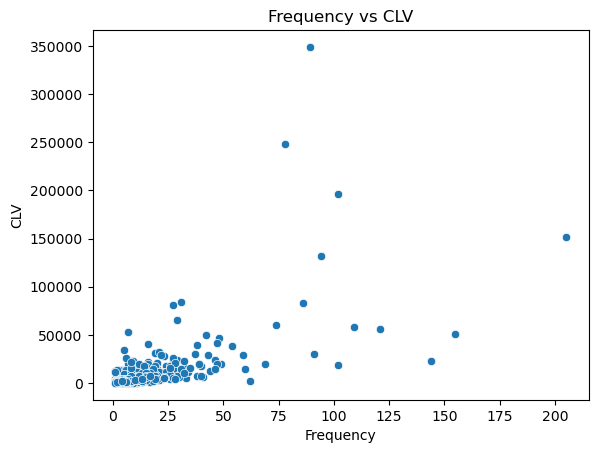

In [36]:
sns.scatterplot(x=rfm['Frequency'], y=rfm['CLV'])
plt.title("Frequency vs CLV")
plt.show()

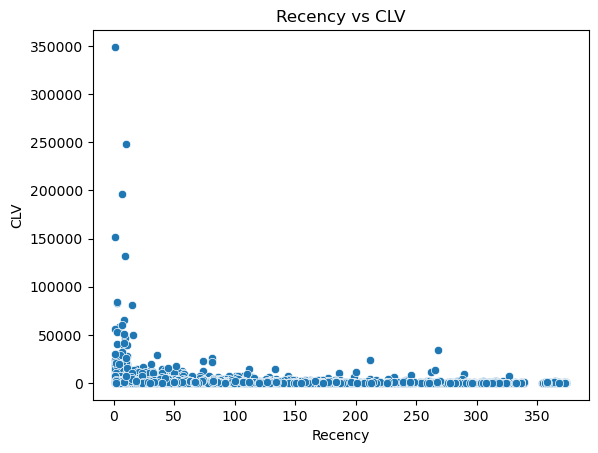

In [37]:
sns.scatterplot(x=rfm['Recency'], y=rfm['CLV'])
plt.title("Recency vs CLV")
plt.show()

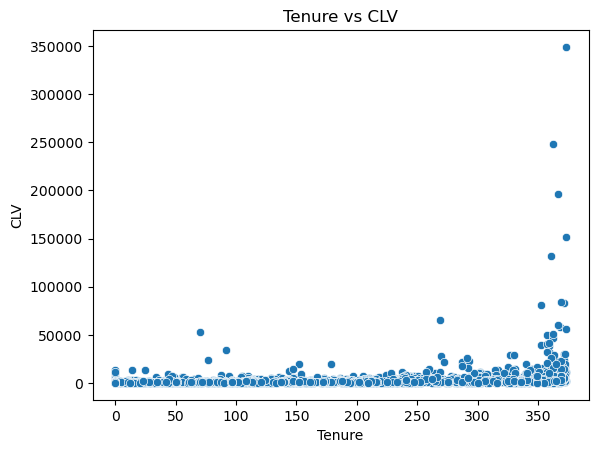

In [38]:
sns.scatterplot(x=rfm['Tenure'], y=rfm['CLV'])
plt.title("Tenure vs CLV")
plt.show()

# Model Comparison

In [39]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression RMSE: 9.837713675634261e-12


In [40]:
print("Deep Learning RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dl)))

Deep Learning RMSE: 10435.187381072845
